X shape: (945, 378)
y shape: (945, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 374, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 187, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 185, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 92, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5888)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       376,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385,475 (1.47 MB)

 Trainable params: 385,475 (1.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.3729 - mae: 0.4139 - val_loss: 0.0803 - val_mae: 0.1962
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1334 - mae: 0.2524 - val_loss: 0.0744 - val_mae: 0.1857
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1267 - mae: 0.2423 - val_loss: 0.0476 - val_mae: 0.1570
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1107 - mae: 0.2282 - val_loss: 0.0518 - val_mae: 0.1677
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1036 - mae: 0.2128 - val_loss: 0.0484 - val_mae: 0.1427
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0815 - mae: 0.1938 - val_loss: 0.0646 - val_mae: 0.1317
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.1006 - mae: 0.2143 - val_loss: 0.0450 - val_mae: 0.1361
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0600 - mae: 0.1677 - val_loss: 0.0377 - val_mae: 0.1141
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

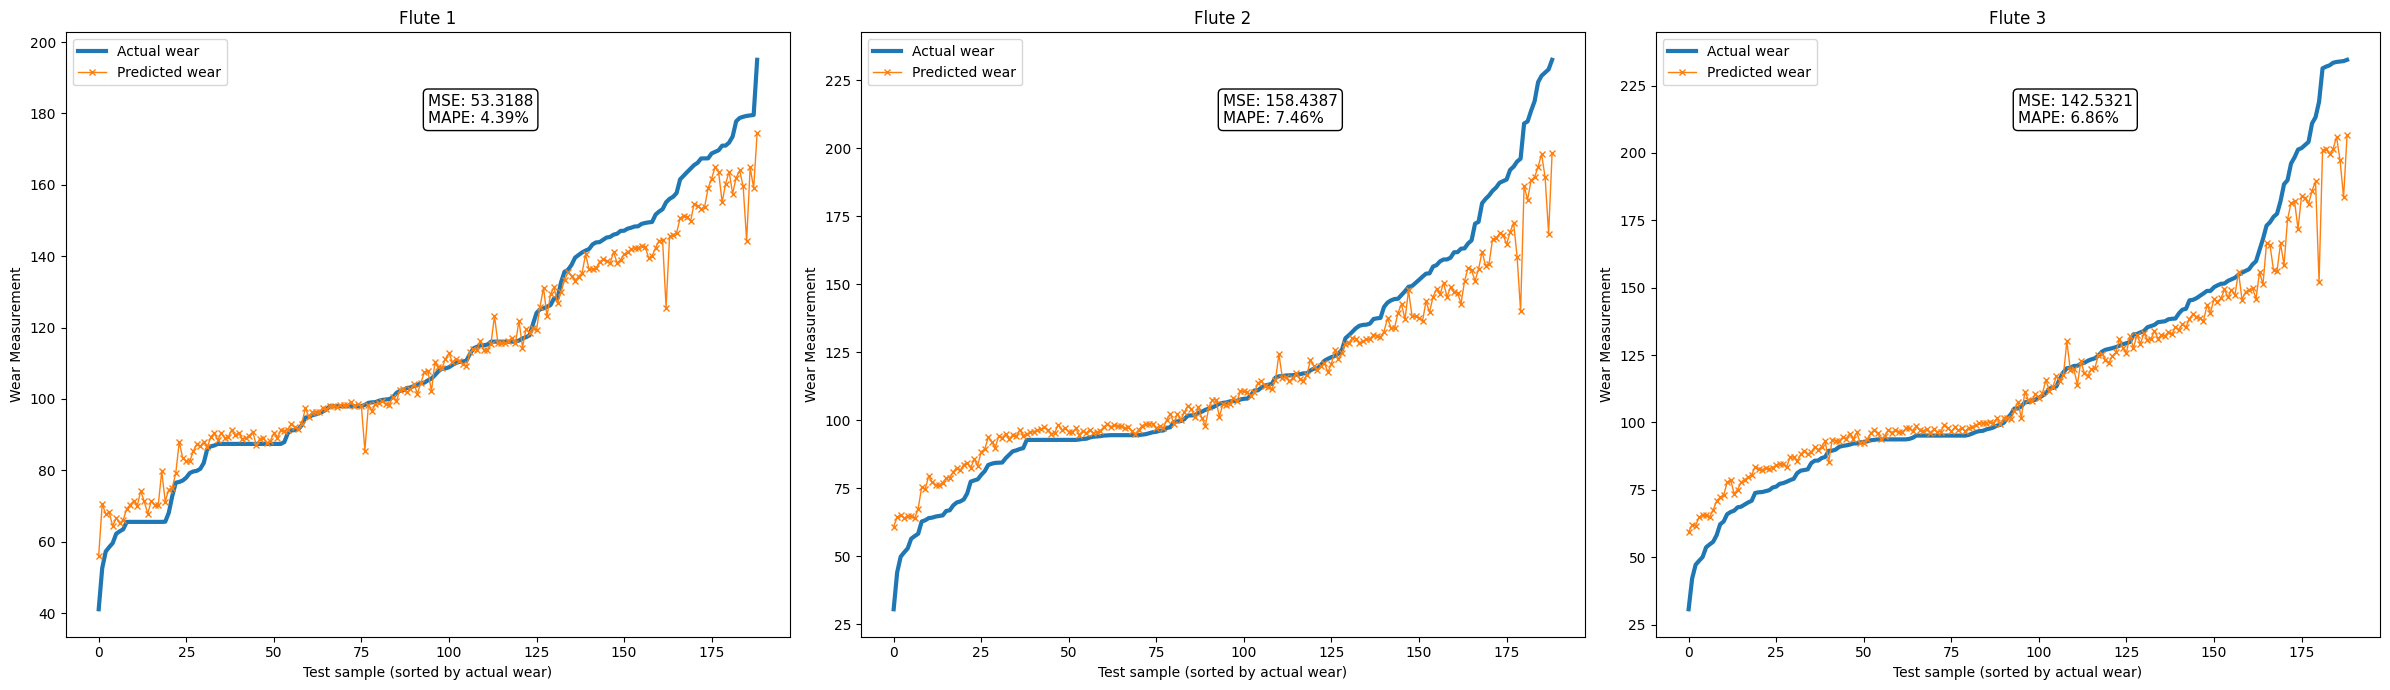

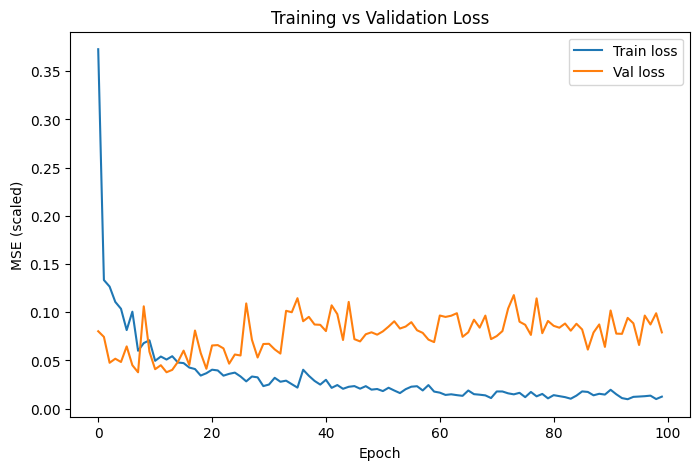

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow.keras import layers, models

# ============================================================
# STEP 1: Combine all three cutters
# ============================================================
df_c1 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c1_aggregated_features.csv")
df_c4 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c4_aggregated_features.csv")
df_c6 = pd.read_csv("C:/Users/shrut/Desktop/IOT/c6_aggregated_features.csv")

df_c1["cutter"] = "C1"
df_c4["cutter"] = "C4"
df_c6["cutter"] = "C6"

df_combined = pd.concat([df_c1, df_c4, df_c6], ignore_index=True)

y = df_combined[["flute_1", "flute_2", "flute_3"]].values
X = df_combined.drop(
    columns=["cut_number", "flute_1", "flute_2", "flute_3", "max_wear", "cutter"]
).values

print("X shape:", X.shape)  # (945, 378)
print("y shape:", y.shape)  # (945, 3)

# ============================================================
# STEP 2: Train/test split + scaling
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# scale y too — CNNs train more stably when targets aren't in the 100s
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# ============================================================
# STEP 3: Reshape for Conv1D -> (samples, features, channels=1)
# ============================================================
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# ============================================================
# STEP 4: Build the CNN
# ============================================================
n_features = X_train_cnn.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_features, 1)),
    layers.Conv1D(filters=32, kernel_size=5, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(3)  # 3 outputs: flute_1, flute_2, flute_3
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

# ============================================================
# STEP 5: Train
# ============================================================
history = model.fit(
    X_train_cnn, y_train_scaled,
    validation_data=(X_test_cnn, y_test_scaled),
    epochs=100,
    batch_size=16,
    verbose=1
)

# ============================================================
# STEP 6: Predict and inverse-scale back to real wear values
# ============================================================
y_pred_scaled = model.predict(X_test_cnn)
y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_actual = y_scaler.inverse_transform(y_test_scaled)  # same as y_test, just confirming round-trip

# ============================================================
# STEP 7: Evaluate per flute
# ============================================================
for i, flute in enumerate(["flute_1", "flute_2", "flute_3"]):
    mse = mean_squared_error(y_actual[:, i], y_pred[:, i])
    mape = mean_absolute_percentage_error(y_actual[:, i], y_pred[:, i]) * 100
    print(f"{flute} -> MSE: {mse:.4f}, MAPE: {mape:.2f}%")

# ============================================================
# STEP 8: Plot actual vs predicted
# ============================================================
def plot_predictions(y_actual, y_pred):
    n_targets = y_actual.shape[1]
    flute_labels = [f"Flute {i+1}" for i in range(n_targets)]
    fig, axes = plt.subplots(1, n_targets, figsize=(24, 7))

    for i in range(n_targets):
        ax = axes[i]
        actual = y_actual[:, i]
        pred = y_pred[:, i]
        order = np.argsort(actual)

        mse = mean_squared_error(actual, pred)
        mape = mean_absolute_percentage_error(actual, pred) * 100

        ax.plot(actual[order], label="Actual wear", linewidth=3, color="tab:blue")
        ax.plot(pred[order], label="Predicted wear", marker="x",
                 markersize=4, linewidth=1, color="tab:orange")
        ax.set_title(flute_labels[i])
        ax.set_xlabel("Test sample (sorted by actual wear)")
        ax.set_ylabel("Wear Measurement")
        ax.legend(loc="upper left")
        ax.text(0.5, 0.85, f"MSE: {mse:.4f}\nMAPE: {mape:.2f}%",
                transform=ax.transAxes, fontsize=11,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"))

    plt.tight_layout()
    plt.show()

plot_predictions(y_actual, y_pred)

# ============================================================
# STEP 9: Training curves (helps spot overfitting)
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()